# XceptionFNO: Detección de Deepfakes con Fourier Neural Operator

## 1. Arquitectura XceptionFNO


In [1]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'torchvision', 'timm', 'albumentations',
    'matplotlib', 'seaborn', 'pandas', 'scikit-learn',
    'opencv-python', 'tqdm'])

0

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image

from src.config import make_config, set_seed, FAKE_CLASSES, MODEL_COLORS
from src.data import build_frame_dataframe, make_loaders, DeepfakeDataset
from src.models import XceptionFNO, FNOBlock, build_model, load_model
from src.engine import train_model, evaluate_by_method
from src.viz import plot_history

torch.backends.cudnn.benchmark = True

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path
MY_ROOT = Path('/home/mariasarachaga/TPF-VA')
CONFIG = make_config(
    DATA_DIR      = MY_ROOT / 'dataset_split',
    OUTPUT_DIR    = MY_ROOT / 'outputs' / 'xception_fno',
    BASELINE_CKPT = MY_ROOT / 'outputs' / 'best_xception.pth',
    FNO_CHANNELS  = 32,
    FNO_MODES     = 8,
    FNO_BLOCKS    = 4,
)
set_seed(CONFIG['SEED'])
print('Configuración lista:')
for k, v in CONFIG.items():
    print(f'  {k:15s}: {v}')
if CONFIG['DEVICE'] == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Configuración lista:
  DATA_DIR       : /home/mariasarachaga/TPF-VA/dataset_split
  OUTPUT_DIR     : /home/mariasarachaga/TPF-VA/outputs/xception_fno
  SEED           : 42
  IMG_SIZE       : 299
  BATCH_SIZE     : 32
  LR             : 0.0001
  LR_HEAD        : 0.001
  WEIGHT_DECAY   : 0.0001
  EPOCHS         : 15
  PATIENCE       : 5
  DROPOUT        : 0.3
  NUM_WORKERS    : 4
  DEVICE         : cuda
  BASELINE_CKPT  : /home/mariasarachaga/TPF-VA/outputs/best_xception.pth
  FNO_CHANNELS   : 32
  FNO_MODES      : 8
  FNO_BLOCKS     : 4
GPU: NVIDIA L4


## 2. Implementación del Fourier Neural Operator

In [4]:
_x     = torch.randn(2, 32, 299, 299)
_block = FNOBlock(32, modes1=16, modes2=16)
_out   = _block(_x)
print(f'FNOBlock: {_x.shape} -> {_out.shape}  ✓')
print(f'Parámetros por bloque: {sum(p.numel() for p in _block.parameters()):,}')
del _x, _block, _out

FNOBlock: torch.Size([2, 32, 299, 299]) -> torch.Size([2, 32, 299, 299])  ✓
Parámetros por bloque: 525,408


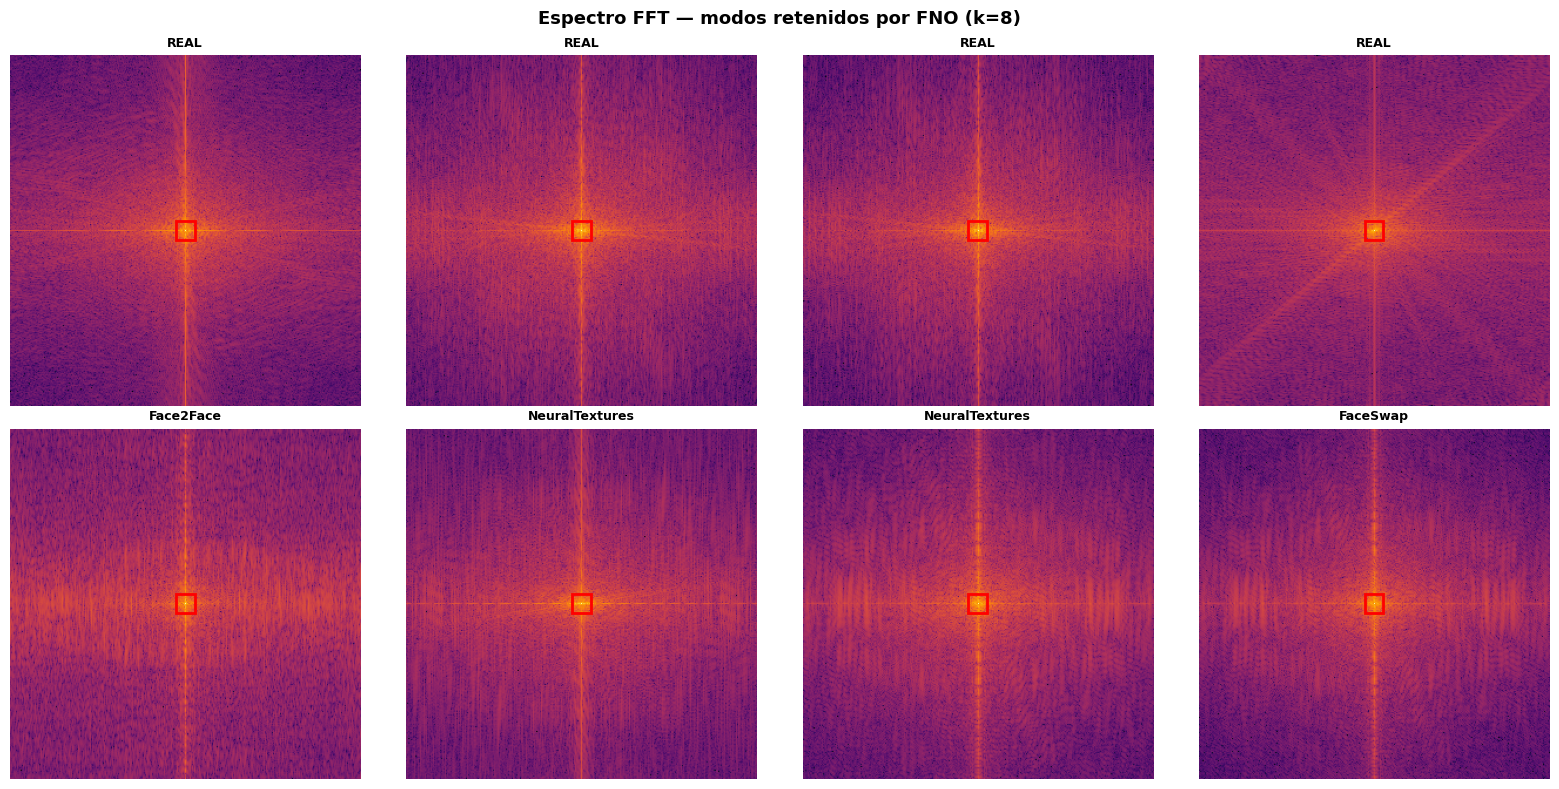

Figura guardada en: /home/mariasarachaga/TPF-VA/outputs/xception_fno
El cuadrado rojo muestra los 8×8 modos retenidos.
Todo lo exterior se trunca a cero (filtro pasa-bajos en Fourier).


In [5]:
def visualize_fno_modes(config, n_examples=4):
    """
    Visualiza qué modos frecuenciales retiene el FNO vs cuáles trunca.
    Muestra la magnitud espectral de imágenes reales (fila superior) 
    y fakes (fila inferior) llenando toda la grilla.
    """
    rows = []
    
    for cls_dir in (config['DATA_DIR'] / 'test').iterdir():
        if not cls_dir.is_dir(): continue
        label = 1 if cls_dir.name in FAKE_CLASSES else 0
        for p in list(cls_dir.rglob('*.jpg'))[:50]:
            rows.append({'path': str(p), 'label': label, 'method': cls_dir.name})
    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, n_examples, figsize=(n_examples * 4, 8))
    fig.suptitle(f'Espectro FFT — modos retenidos por FNO (k={config["FNO_MODES"]})',
                 fontsize=13, fontweight='bold')

    for label_val in [0, 1]:
        subset = df[df['label'] == label_val].sample(n_examples, random_state=42 + label_val)
        
        for i, (_, row) in enumerate(subset.iterrows()):
            ax = axes[label_val, i]
            
            img  = np.array(Image.open(row['path']).convert('RGB').resize(
                (config['IMG_SIZE'], config['IMG_SIZE'])
            ))
            gray = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]).astype(np.float32)
            mag  = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray))))

            ax.imshow(mag, cmap='inferno')
            
            k = config['FNO_MODES']
            H, W = mag.shape
            rect = plt.Rectangle((W//2 - k, H//2 - k), 2*k, 2*k,
                                 edgecolor='red', facecolor='none', linewidth=2)
            ax.add_patch(rect)
            
            tag = 'REAL' if label_val == 0 else row['method']
            ax.set_title(tag, fontsize=9, fontweight='bold')
            ax.axis('off')

    axes[0, 0].set_ylabel('Real', fontsize=10)
    axes[1, 0].set_ylabel('Fake', fontsize=10)

    plt.tight_layout()
    plt.savefig(config['OUTPUT_DIR'] / 'fno_modes_visualization.png', dpi=150)
    plt.show()
    
    print(f'Figura guardada en: {config["OUTPUT_DIR"]}')
    print(f'El cuadrado rojo muestra los {config["FNO_MODES"]}×{config["FNO_MODES"]} modos retenidos.')
    print(f'Todo lo exterior se trunca a cero (filtro pasa-bajos en Fourier).')


visualize_fno_modes(CONFIG)

In [6]:
df = build_frame_dataframe(CONFIG['DATA_DIR'])
print(f'Total: {len(df):,}')
print(df.groupby(['split', 'label']).size().unstack(fill_value=0))

train_loader, val_loader, test_loader = make_loaders(df, CONFIG)

model = XceptionFNO(
    dropout      = CONFIG['DROPOUT'],
    fno_channels = CONFIG['FNO_CHANNELS'],
    modes        = CONFIG['FNO_MODES'],
    num_blocks   = CONFIG['FNO_BLOCKS'],
).to(CONFIG['DEVICE'])

print("Modelo cargado exitosamente en:", CONFIG['DEVICE'])

Total: 60,001
label     0      1
split             
test   1400   7001
train  7200  36000
val    1400   7000
Train: 43,200 | Val: 8,400 | Test: 8,401


/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


Modelo cargado exitosamente en: cuda


In [7]:
optimizer = torch.optim.AdamW([
    {'params': list(model.backbone.parameters()), 'lr': CONFIG['LR']},
    {'params': (list(model.lift.parameters()) +
                list(model.fno_blocks.parameters()) +
                list(model.project.parameters()) +
                list(model.spatial_norm.parameters()) +
                list(model.fno_norm.parameters()) +
                list(model.gate.parameters()) +
                list(model.classifier.parameters())), 'lr': CONFIG['LR_HEAD']},
], weight_decay=CONFIG['WEIGHT_DECAY'])

criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'], eta_min=1e-6)
scaler = None

print('Optimizer, criterion, scheduler listos.')
print(f'  LR backbone : {optimizer.param_groups[0]["lr"]}')
print(f'  LR rama FNO : {optimizer.param_groups[1]["lr"]}')
print(f'  AMP activo  : False (incompatible con pesos cfloat de FNO)')

Optimizer, criterion, scheduler listos.
  LR backbone : 0.0001
  LR rama FNO : 0.001
  AMP activo  : False (incompatible con pesos cfloat de FNO)


In [8]:
print('Entrenando XceptionFNO\n')
history = train_model(
    model, 'xception_fno', train_loader, val_loader,
    optimizer, criterion, scheduler, CONFIG, scaler=scaler
)

Entrenando XceptionFNO



Epoch 01/15 | train_loss=0.6404 train_acc=0.6153 | val_loss=0.4741 val_acc=0.7624 val_auc=0.7516  ✓ checkpoint guardado (AUC=0.7516)


Epoch 02/15 | train_loss=0.5137 train_acc=0.7301 | val_loss=0.7224 val_acc=0.6487 val_auc=0.7778  ✓ checkpoint guardado (AUC=0.7778)


Epoch 03/15 | train_loss=0.4268 train_acc=0.7816 | val_loss=0.4769 val_acc=0.8098 val_auc=0.7911  ✓ checkpoint guardado (AUC=0.7911)


Epoch 04/15 | train_loss=0.3612 train_acc=0.8225 | val_loss=0.5800 val_acc=0.8187 val_auc=0.8085  ✓ checkpoint guardado (AUC=0.8085)


...

Epoch 08/15 | train_loss=0.2349 train_acc=0.8817 | val_loss=0.6567 val_acc=0.8140 val_auc=0.8162  (sin mejora 1/5)


Epoch 09/15 | train_loss=0.2110 train_acc=0.8925 | val_loss=0.8385 val_acc=0.8208 val_auc=0.8162  (sin mejora 2/5)


Epoch 10/15 | train_loss=0.1922 train_acc=0.9010 | val_loss=1.0328 val_acc=0.8292 val_auc=0.8080  (sin mejora 3/5)


Epoch 11/15 | train_loss=0.1756 train_acc=0.9096 | val_loss=1.0572 val_acc=0.8198 val_auc=0.8105  (sin mejora 4/5)


Epoch 12/15 | train_loss=0.1662 train_acc=0.9118 | val_loss=1.2249 val_acc=0.8281 val_auc=0.8038  (sin mejora 5/5)

Early stopping en época 12.


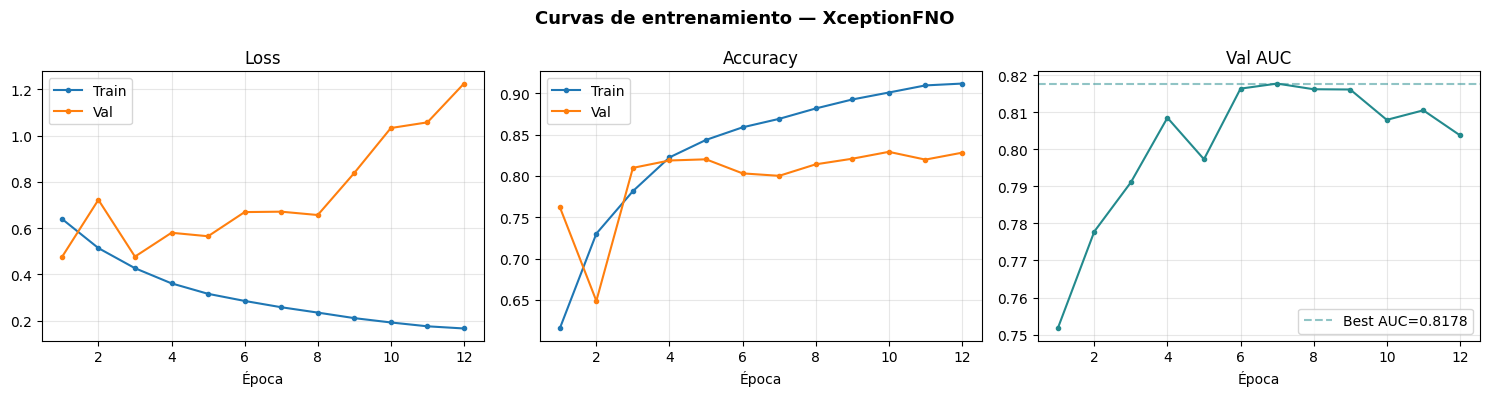

In [9]:
plot_history(history, 'XceptionFNO', CONFIG['OUTPUT_DIR'])

In [10]:
print('\nEvaluando en test set...\n')
results_df = evaluate_by_method(model, df, CONFIG)
results_df.to_csv(CONFIG['OUTPUT_DIR'] / 'test_results_by_method.csv', index=False)
print(f'\nAUC promedio: {results_df["AUC"].mean():.4f}')


Evaluando en test set...



  Deepfakes             AUC=0.8531  Acc=0.7271  F1=0.7754


  Face2Face             AUC=0.8001  Acc=0.6979  F1=0.7452


  FaceShifter           AUC=0.8550  Acc=0.7339  F1=0.7822


  FaceSwap              AUC=0.8168  Acc=0.7069  F1=0.7547


  NeuralTextures        AUC=0.7545  Acc=0.6721  F1=0.7174

AUC promedio: 0.8159


/home/mariasarachaga/.local/lib/python3.10/site-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(


xception — parámetros entrenables: 20,809,001
Baseline cargado — val AUC: 0.8222460204081633


  Deepfakes             AUC=0.8769  Acc=0.7332  F1=0.7791


  Face2Face             AUC=0.7981  Acc=0.6946  F1=0.7388


  FaceShifter           AUC=0.8608  Acc=0.7329  F1=0.7787


  FaceSwap              AUC=0.8387  Acc=0.7105  F1=0.7556


  NeuralTextures        AUC=0.7438  Acc=0.6654  F1=0.7064

Comparación: XceptionFNO vs Xception baseline

        method  AUC_fno  AUC_baseline   Delta
     Deepfakes   0.8531        0.8769 -0.0237
     Face2Face   0.8001        0.7981  0.0019
   FaceShifter   0.8550        0.8608 -0.0059
      FaceSwap   0.8168        0.8387 -0.0219
NeuralTextures   0.7545        0.7438  0.0106

Δ AUC promedio: -0.0078


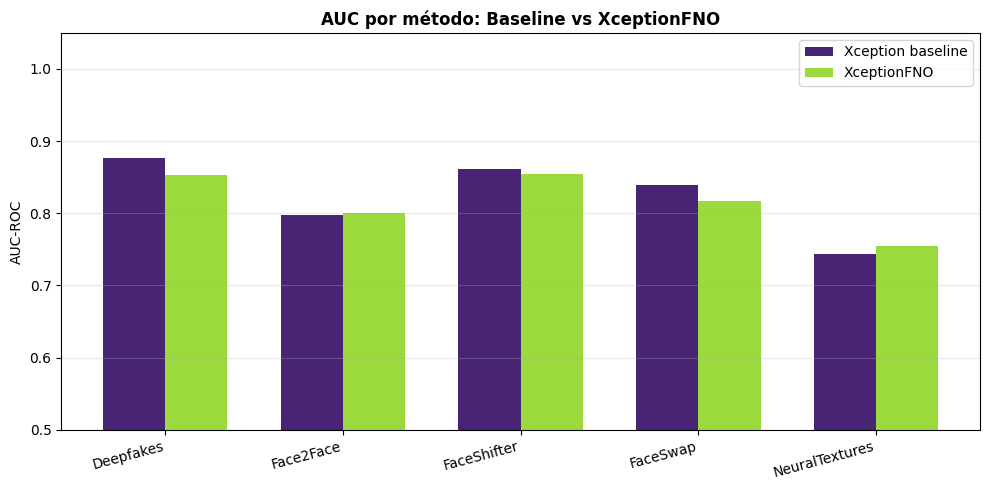

In [11]:
BASELINE_AVAILABLE = CONFIG['BASELINE_CKPT'].exists()

if BASELINE_AVAILABLE:
    baseline = build_model('xception', CONFIG['DEVICE'])
    baseline, baseline_val_auc, _ = load_model(baseline, CONFIG['BASELINE_CKPT'], CONFIG['DEVICE'])
    print(f'Baseline cargado — val AUC: {baseline_val_auc}')

    baseline_df = evaluate_by_method(baseline, df, CONFIG)[['method', 'AUC']] \
                        .rename(columns={'AUC': 'AUC_baseline'})

    comparison = results_df[['method', 'AUC']].rename(columns={'AUC': 'AUC_fno'}) \
                            .merge(baseline_df, on='method')
    comparison['Delta'] = comparison['AUC_fno'] - comparison['AUC_baseline']

    print('\nComparación: XceptionFNO vs Xception baseline\n')
    print(comparison.to_string(index=False, float_format='{:.4f}'.format))
    print(f'\nΔ AUC promedio: {comparison["Delta"].mean():+.4f}')

    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(len(comparison)), 0.35
    ax.bar(x - w/2, comparison['AUC_baseline'], w, label='Xception baseline', color=MODEL_COLORS['Baseline'])
    ax.bar(x + w/2, comparison['AUC_fno'],      w, label='XceptionFNO',       color=MODEL_COLORS['FNO'])
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['method'], rotation=15, ha='right')
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('AUC-ROC')
    ax.set_title('AUC por método: Baseline vs XceptionFNO', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(CONFIG['OUTPUT_DIR'] / 'auc_comparison.png', dpi=150)
    plt.show()
    comparison.to_csv(CONFIG['OUTPUT_DIR'] / 'auc_comparison.csv', index=False)
else:
    print(f'[!] Baseline no encontrado en {CONFIG["BASELINE_CKPT"]}')

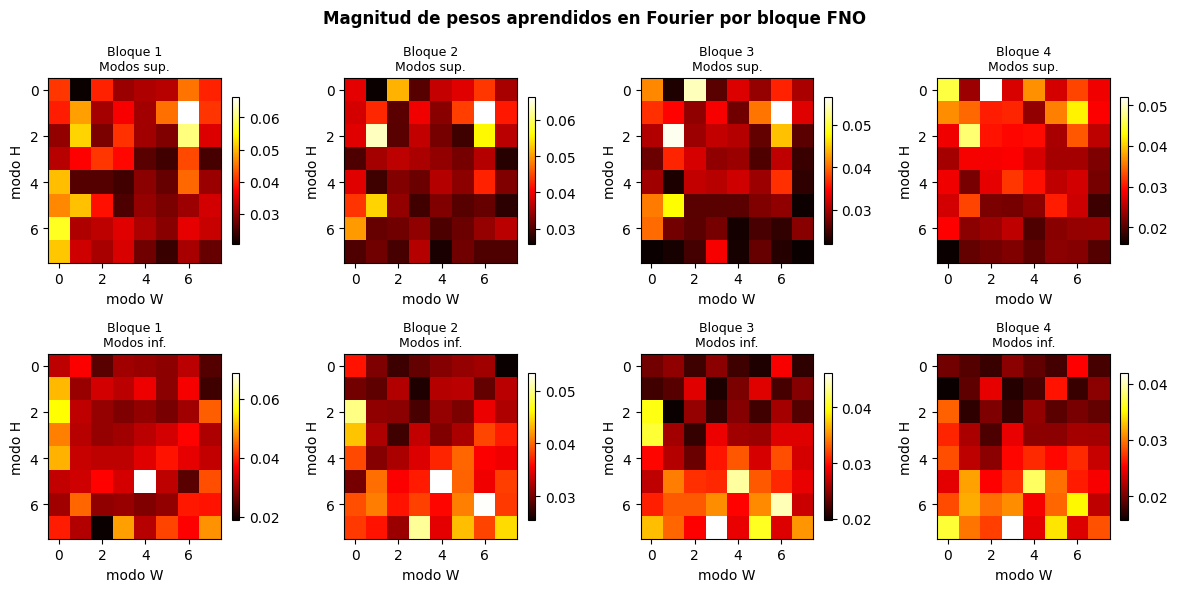

Si los pesos tienen estructura no uniforme, el FNO aprendió
preferencia por ciertos modos frecuenciales sobre otros.


In [12]:
def visualize_learned_fourier_weights(model, config):
    """
    Visualiza la magnitud de los pesos complejos aprendidos por cada
    SpectralConv2d. Si el FNO aprendió firma frecuencial relevante,
    se esperan pesos con mayor magnitud en ciertas frecuencias.
    """
    fig, axes = plt.subplots(2, config['FNO_BLOCKS'], figsize=(config['FNO_BLOCKS']*3, 6))
    fig.suptitle('Magnitud de pesos aprendidos en Fourier por bloque FNO',
                 fontsize=12, fontweight='bold')

    for i, block in enumerate(model.fno_blocks):
        sc = block.spectral
        w1_mag = sc.weights1.detach().abs().mean(dim=(0,1)).cpu().numpy()
        w2_mag = sc.weights2.detach().abs().mean(dim=(0,1)).cpu().numpy()

        im1 = axes[0, i].imshow(w1_mag, cmap='hot', aspect='auto')
        axes[0, i].set_title(f'Bloque {i+1}\nModos sup.', fontsize=9)
        axes[0, i].set_xlabel('modo W'); axes[0, i].set_ylabel('modo H')
        plt.colorbar(im1, ax=axes[0, i], shrink=0.8)

        im2 = axes[1, i].imshow(w2_mag, cmap='hot', aspect='auto')
        axes[1, i].set_title(f'Bloque {i+1}\nModos inf.', fontsize=9)
        axes[1, i].set_xlabel('modo W'); axes[1, i].set_ylabel('modo H')
        plt.colorbar(im2, ax=axes[1, i], shrink=0.8)

    plt.tight_layout()
    plt.savefig(config['OUTPUT_DIR'] / 'fourier_weights_learned.png', dpi=150)
    plt.show()
    print('Si los pesos tienen estructura no uniforme, el FNO aprendió')
    print('preferencia por ciertos modos frecuenciales sobre otros.')


visualize_learned_fourier_weights(model, CONFIG)

In [13]:
print('Resumen XceptionFNO\n')
best_ep  = history.loc[history['val_auc'].idxmax(), 'epoch']
best_auc = history['val_auc'].max()
print(f'Mejor val AUC : {best_auc:.4f} (época {int(best_ep)})')
print(f'\nAUC test por método:')
for _, row in results_df.iterrows():
    bar = '█' * int(row['AUC'] * 20)
    print(f'  {row["method"]:20s} {row["AUC"]:.4f}  {bar}')
print(f'\nAUC promedio test : {results_df["AUC"].mean():.4f}')
print(f'Modos FNO         : {CONFIG["FNO_MODES"]}×{CONFIG["FNO_MODES"]}')
print(f'Bloques FNO       : {CONFIG["FNO_BLOCKS"]}')
print(f'Artefactos en     : {CONFIG["OUTPUT_DIR"]}')

Resumen XceptionFNO

Mejor val AUC : 0.8178 (época 7)

AUC test por método:
  Deepfakes            0.8531  █████████████████
  Face2Face            0.8001  ████████████████
  FaceShifter          0.8550  █████████████████
  FaceSwap             0.8168  ████████████████
  NeuralTextures       0.7545  ███████████████

AUC promedio test : 0.8159
Modos FNO         : 8×8
Bloques FNO       : 4
Artefactos en     : /home/mariasarachaga/TPF-VA/outputs/xception_fno
